#Before starting scraping from flower aura site we have to import all important library for it.

In [470]:
from bs4 import BeautifulSoup
from textblob import  TextBlob
import requests
import pandas as  pd
import numpy as np
import seaborn as sns
import matplotlib.pyp as plt


In [393]:
#Creating lists to store data.
Name = []
City = []
Review = []
Rating = []
Posted_on = []

In [446]:
url = "https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page="

for i in range(1,51):
    cnp = url+str(i)
    url_new = cnp

    r = requests.get(url_new)
    r

    soup = BeautifulSoup(r.text,"html.parser")


    main = soup.find("div",{"class":"review-left-container"}) 
    sub = main.find_all("div",{"class":"new-review-card-container"})


    for i in sub:
        name = i.find("span",{"class":"review-author-name"})
        Name.append(name.text.title())

        city = i.find("span",{"class":"review-meta-details"})
        City.append(city.text.title())

        rating = i.find("div",{"class":"review-count-star-container"})
        Rating.append(rating.text.title())

        date = i.find_all("span")
        try:
            Posted_on.append(date[4].text) 
        except:
            Posted_on.append(np.nan)

        review = i.find_all("div")
        try:
            Review.append(review[-1].text)
            
        except:
            Review.append(np.nan)

In [450]:
df = pd.DataFrame({"Name":Name,"City":City,"Posted_on":Posted_on,"Review":Review,"Rating":Rating})

In [451]:
df

,Name,City,Posted_on,Review,Rating
0,Ramesh Kumar Pariyar,Bengaluru,Posted On : 7th Jan 2026,Great experience with FlowerAura.Delivery was ...,5
1,Anki M,Shillong,Posted On : 21st Oct 2025,Fresh flowers...liked it.,5
2,Suraj Chaunal,Noida,Posted On : 23rd Sep 2025,the flowers were fresh and colorful. TBH they ...,5
3,Bakiyalakshmi,Bangalore,Posted On : 22nd Sep 2025,"Very fresh flowers, delivered on time with bea...",5
4,Pulak.Pal77,Kolkata,Posted On : 19th Sep 2025,Roses quality is very nice.,5
...,...,...,...,...,...
495,Meghna Chaturvedi,Lucknow,Posted On : 7th Sep 2023,The flowers arrived at time and they were fres...,5
496,Jidhu Joshua,Jodhpur,Posted On : 10th Sep 2023,It was amazing....!!!,5
497,Arun,Hyderabad,Posted On : 9th Sep 2023,Thanks for the flowers,4
498,Prernasaini,Gurgaon,Posted On : 8th Sep 2023,Thank you so much,5


In [452]:
#lets get dates as date's standard format:-

a = "Posted  On : 31st Aug 2025"
x = a.index(":")
print(a[x+2:])

31st Aug 2025


In [453]:
#create function which will extract all dates & occasions within the DF in there standard format:-
def extract(value):
    try:
        x = value.index(":")
        return value[x+2:]
    except:
        return np.nan
df["Posted_on"]= df["Posted_on"].apply(extract)
df

,Name,City,Posted_on,Review,Rating
0,Ramesh Kumar Pariyar,Bengaluru,7th Jan 2026,Great experience with FlowerAura.Delivery was ...,5
1,Anki M,Shillong,21st Oct 2025,Fresh flowers...liked it.,5
2,Suraj Chaunal,Noida,23rd Sep 2025,the flowers were fresh and colorful. TBH they ...,5
3,Bakiyalakshmi,Bangalore,22nd Sep 2025,"Very fresh flowers, delivered on time with bea...",5
4,Pulak.Pal77,Kolkata,19th Sep 2025,Roses quality is very nice.,5
...,...,...,...,...,...
495,Meghna Chaturvedi,Lucknow,7th Sep 2023,The flowers arrived at time and they were fres...,5
496,Jidhu Joshua,Jodhpur,10th Sep 2023,It was amazing....!!!,5
497,Arun,Hyderabad,9th Sep 2023,Thanks for the flowers,4
498,Prernasaini,Gurgaon,8th Sep 2023,Thank you so much,5


In [454]:
#removing all suffix:- 

rep = ["th","st","rd","nd"]
for i in rep:
    df["Posted_on"]= df["Posted_on"].str.replace(i,"")
df

,Name,City,Posted_on,Review,Rating
0,Ramesh Kumar Pariyar,Bengaluru,7 Jan 2026,Great experience with FlowerAura.Delivery was ...,5
1,Anki M,Shillong,21 Oct 2025,Fresh flowers...liked it.,5
2,Suraj Chaunal,Noida,23 Sep 2025,the flowers were fresh and colorful. TBH they ...,5
3,Bakiyalakshmi,Bangalore,22 Sep 2025,"Very fresh flowers, delivered on time with bea...",5
4,Pulak.Pal77,Kolkata,19 Sep 2025,Roses quality is very nice.,5
...,...,...,...,...,...
495,Meghna Chaturvedi,Lucknow,7 Sep 2023,The flowers arrived at time and they were fres...,5
496,Jidhu Joshua,Jodhpur,10 Sep 2023,It was amazing....!!!,5
497,Arun,Hyderabad,9 Sep 2023,Thanks for the flowers,4
498,Prernasaini,Gurgaon,8 Sep 2023,Thank you so much,5


In [460]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Name          500 non-null    object        
 1   City          500 non-null    object        
 2   Posted_on     500 non-null    datetime64[ns]
 3   Review        500 non-null    object        
 4   Rating        500 non-null    float64       
 5   Polarity      500 non-null    float64       
 6   Subjectivity  500 non-null    float64       
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 27.5+ KB


In [459]:
df["Posted_on"] = pd.to_datetime(df["Posted_on"])
df["Rating"] = df["Rating"].astype("float")
df["Polarity"] = [TextBlob(i).sentiment.polarity for i in df["Review"]]
df["Subjectivity"] = [TextBlob(i).subjectivity for i in df["Review"]]
df

,Name,City,Posted_on,Review,Rating,Polarity,Subjectivity
0,Ramesh Kumar Pariyar,Bengaluru,2026-01-07,Great experience with FlowerAura.Delivery was ...,5.0,0.482143,0.507143
1,Anki M,Shillong,2025-10-21,Fresh flowers...liked it.,5.0,0.300000,0.500000
2,Suraj Chaunal,Noida,2025-09-23,the flowers were fresh and colorful. TBH they ...,5.0,0.262500,0.400000
3,Bakiyalakshmi,Bangalore,2025-09-22,"Very fresh flowers, delivered on time with bea...",5.0,0.532381,0.740476
4,Pulak.Pal77,Kolkata,2025-09-19,Roses quality is very nice.,5.0,0.780000,1.000000
...,...,...,...,...,...,...,...
495,Meghna Chaturvedi,Lucknow,2023-09-07,The flowers arrived at time and they were fres...,5.0,0.575000,0.750000
496,Jidhu Joshua,Jodhpur,2023-09-10,It was amazing....!!!,5.0,1.000000,0.900000
497,Arun,Hyderabad,2023-09-09,Thanks for the flowers,4.0,0.200000,0.200000
498,Prernasaini,Gurgaon,2023-09-08,Thank you so much,5.0,0.200000,0.200000


In [461]:
#adding Polarity to know how it has been performing:-

p = df["Polarity"].mean()
if p <= 0:
    print("Negative")
else:
    print("Positive")

Positive


In [462]:
def score(value):
    if value <= 0:
        return"Negative"
    else:
        return"Positive"
df["Score"]= df["Polarity"].apply(score)
df

,Name,City,Posted_on,Review,Rating,Polarity,Subjectivity,Score
0,Ramesh Kumar Pariyar,Bengaluru,2026-01-07,Great experience with FlowerAura.Delivery was ...,5.0,0.482143,0.507143,Positive
1,Anki M,Shillong,2025-10-21,Fresh flowers...liked it.,5.0,0.300000,0.500000,Positive
2,Suraj Chaunal,Noida,2025-09-23,the flowers were fresh and colorful. TBH they ...,5.0,0.262500,0.400000,Positive
3,Bakiyalakshmi,Bangalore,2025-09-22,"Very fresh flowers, delivered on time with bea...",5.0,0.532381,0.740476,Positive
4,Pulak.Pal77,Kolkata,2025-09-19,Roses quality is very nice.,5.0,0.780000,1.000000,Positive
...,...,...,...,...,...,...,...,...
495,Meghna Chaturvedi,Lucknow,2023-09-07,The flowers arrived at time and they were fres...,5.0,0.575000,0.750000,Positive
496,Jidhu Joshua,Jodhpur,2023-09-10,It was amazing....!!!,5.0,1.000000,0.900000,Positive
497,Arun,Hyderabad,2023-09-09,Thanks for the flowers,4.0,0.200000,0.200000,Positive
498,Prernasaini,Gurgaon,2023-09-08,Thank you so much,5.0,0.200000,0.200000,Positive


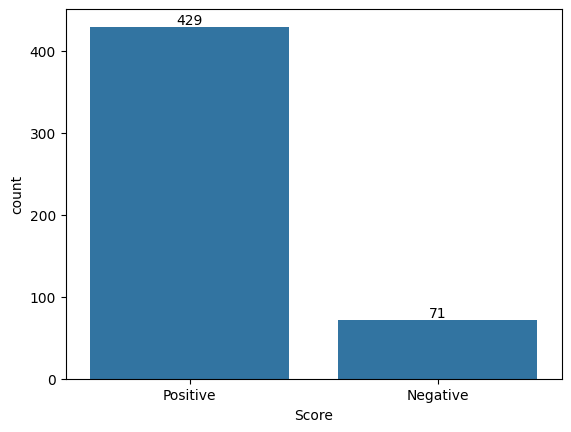

In [471]:
#adding barplot to get the idea of positive and negative reviews:-

ax = sns.countplot(x=df["Score"], data = df)

ax.bar_label(container = ax.containers[0])
plt.show()

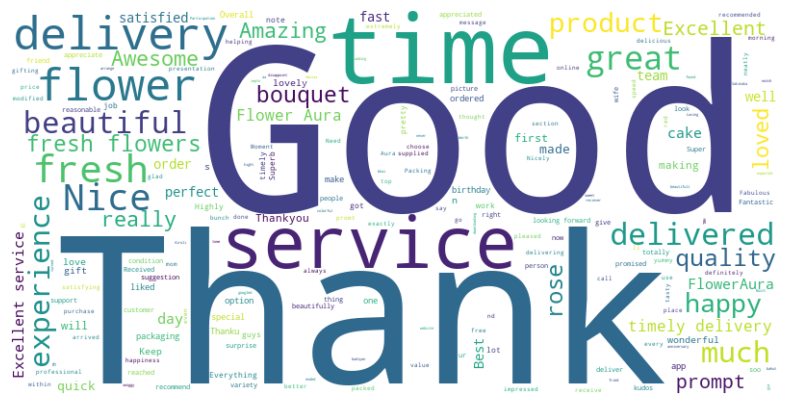

In [469]:
from wordcloud import WordCloud , STOPWORDS
import matplotlib.pyplot as plt

#Two DataFrame created for postive and negative wordcloud

df_pos = df.loc[(df["Score"]=="Positive")]
df_neg = df.loc[(df["Score"]=="Negative")]

# For Positive wordcloud

text = " ".join(text for text in df_pos["Review"])
wordcloud = WordCloud(width=800, height=400, 
                      background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

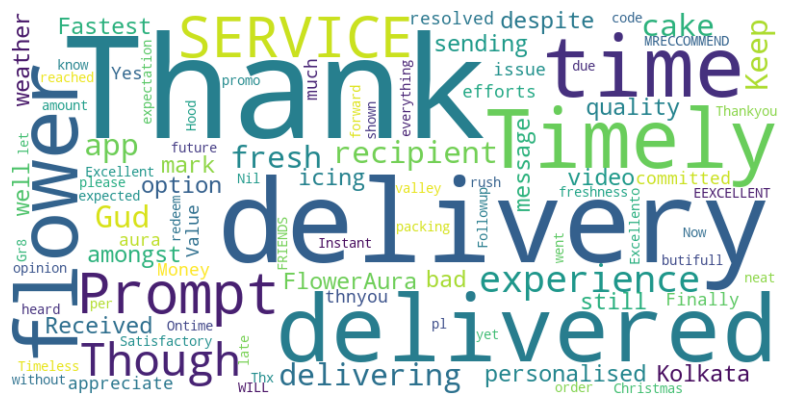

In [473]:
#For negative wordcloud


text = " ".join(text for text in df_neg["Review"])
wordcloud = WordCloud(width=800, height=400, 
                      background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [475]:
# finding correlation between ratings and polarity:-

correlation = df["Rating"].corr(df["Polarity"])
print("Correlation between Ratings and Polarity:", correlation)

Correlation between Ratings and Polarity: -0.01618532723206134


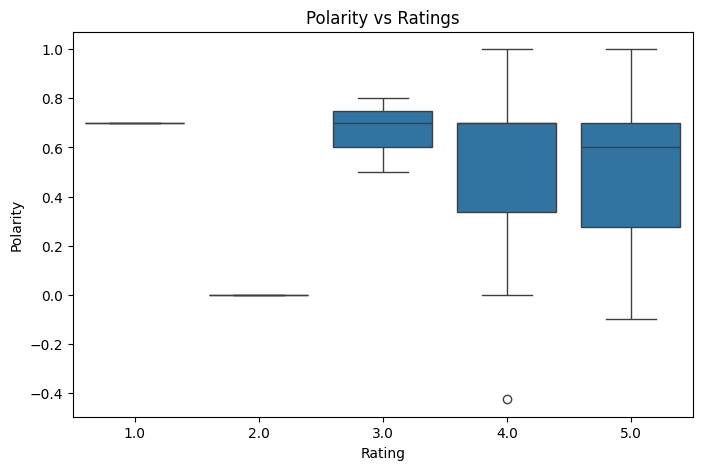

In [477]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Rating", y="Polarity", data=df)
plt.title("Polarity vs Ratings")
plt.show()

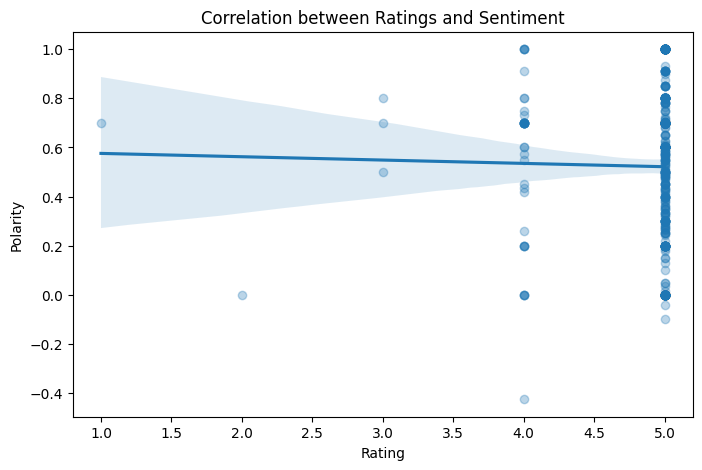

In [478]:
plt.figure(figsize=(8,5))
sns.regplot(x="Rating", y="Polarity", data=df, scatter_kws={"alpha":0.3})
plt.title("Correlation between Ratings and Sentiment")
plt.show()

In [480]:
#calculatig review length written by customers whether it is Positive or negative:- 

df["Review_length"] = df["Review"].apply(lambda x: len(str(x).split()))  # word count
df["Review_length"]

0      19
1       3
2      14
3      17
4       5
       ..
495    12
496     3
497     4
498     4
499    44
Name: Review_length, Length: 500, dtype: int64

In [481]:

corr = df["Review_length"].corr(df["Polarity"])
print("Correlation between Review Length and Sentiment Polarity:", corr)

Correlation between Review Length and Sentiment Polarity: -0.14012436365031355


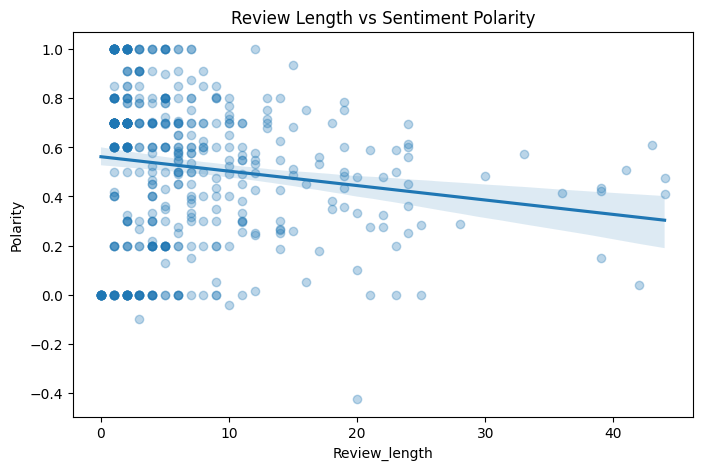

In [482]:
plt.figure(figsize=(8,5))
sns.regplot(x="Review_length", y="Polarity", data=df, scatter_kws={"alpha":0.3})
plt.title("Review Length vs Sentiment Polarity")
plt.show()

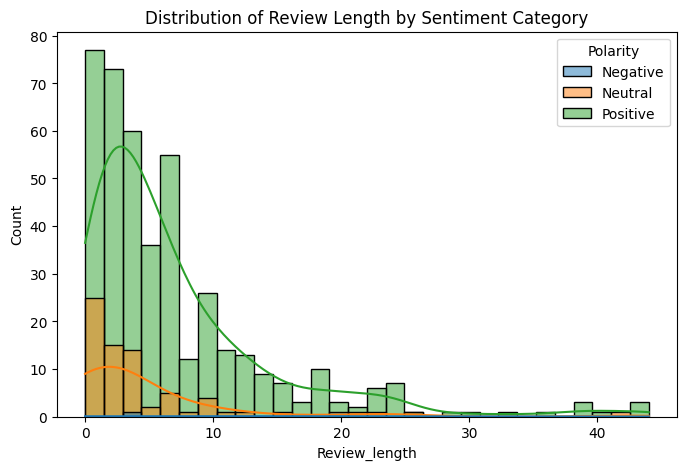

In [483]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Review_length", hue=pd.cut(df["Polarity"], bins=[-1,-0.1,0.1,1], labels=["Negative","Neutral","Positive"]), kde=True)
plt.title("Distribution of Review Length by Sentiment Category")
plt.show()